<a href="https://colab.research.google.com/github/EmIbrahimovic/sp26_6_4110_hw_colabs/blob/main/HW05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 5

## Imports and Utilities
**Note**: these imports and functions are available in catsoop. You do not need to copy them in.

In [1]:
!pip install pyperplan
!pip install multiprocess

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 kB 3.1 MB/s eta 0:00:00


In [2]:
from abc import abstractmethod
import dataclasses
import math
import random
import numpy as np

In [3]:

from typing import (Callable, Iterable, List, Sequence, Tuple, Dict, Optional,
                    Any, Union)

from abc import abstractmethod
import collections
import itertools
import functools
import random
import heapq as hq
import numpy as np

########## Graph-Search-Related Utilities and Class Definitions ##########

State = Any
Action = Any

StateSeq = List[State]
ActionSeq = List[State]
CostSeq = RewardSeq = List[float]


class Problem(object):
  """The abstract base class for either a path cost problem or a reward problem."""

  def __init__(self, initial: State):
    self.initial = initial

  @abstractmethod
  def actions(self, state: State) -> Iterable[Action]:
    """Returns the allowed actions in a given state.

    The result would typically be a list. But if there are many actions,
    consider yielding them one at a time in an iterator,
    rather than building them all at once.
    """
    ...

  @abstractmethod
  def step(self, state: State, action: Action) -> State:
    """Returns the next state when executing a given action in a given state.

    The action must be one of self.actions(state).
    """
    ...


class PathCostProblem(Problem):
  """An abstract class for a path cost problem, based on AIMA.

  To formalize a path cost problem, you should subclass from this and implement
  the abstract methods.
  Then you will create instances of your subclass and solve them with the
  various search functions.
  """

  @abstractmethod
  def goal_test(self, state: State) -> bool:
    """Checks if the state is a goal."""
    ...

  @abstractmethod
  def step_cost(self, state1: State, action: Action, state2: State) -> float:
    """Returns the cost incurred at state2 from state1 via action."""
    ...

  def h(self, state: State) -> float:
    """Returns the heuristic value, a lower bound on the distance to goal."""
    return 0


class RewardProblem(Problem):
  """An abstract class for a finite-horizon reward problem, based on AIMA.

  To formalize a reward problem, you should subclass from this and implement
  the abstract methods.
  Then you will create instances of your subclass and solve them with the
  various search functions.
  """

  def __init__(self, initial: State, horizon: int):
    self.initial = initial
    self.horizon = horizon

  @abstractmethod
  def reward(self, state1: State, action: Action, state2: State) -> float:
    """Returns the reward given at state2 from state1 via action.

    A reward at each step must be no greater than `self.rmax`.
    """
    ...

  @property
  @abstractmethod
  def rmax(self) -> float:
    """Returns the maximum reward per step."""
    ...

# A useful data structure for best-first search
Node = collections.namedtuple("Node",
                              ["state", "parent", "action", "cost", "g"])

def run_best_first_search(
    problem: PathCostProblem,
    get_priority: Callable[[Node], float],
    step_budget: int = 1000) -> Tuple[StateSeq, ActionSeq, CostSeq, int]:
  '''A generic heuristic search implementation.

  Depending on `get_priority`, can implement A*, GBFS, or UCS.

  The `get_priority` function here should determine the order
  in which nodes are expanded. For example, if you want to
  use path cost as part of this determination, then the
  path cost (node.g) should appear inside of get_priority,
  rather than in this implementation of `run_best_first_search`.

  Important: for determinism (and to make sure our tests pass),
  please break ties using the state itself. For example,
  if you would've otherwise sorted by `get_priority(node)`, you
  should now sort by `(get_priority(node), node.state)`.

  Args:
    problem: a path cost problem.
    get_priority: a callable taking in a search Node and returns the priority
    step_budget: maximum number of `problem.step` before giving up.

  Returns:
    state_sequence: A list of states.
    action_sequence: A list of actions.
    cost_sequence: A list of costs.
    num_steps: number of taken `problem.step`s. Must be less than or equal to `step_budget`.

  Raises:
    error: SearchFailed, if no plan is found.
  '''
  num_steps = 0
  frontier = []
  reached = {}

  root_node = Node(state=problem.initial,
                   parent=None,
                   action=None,
                   cost=None,
                   g=0)
  hq.heappush(frontier, (get_priority(root_node), problem.initial, root_node))
  reached[problem.initial] = root_node
  num_expansions = 0

  while frontier:
    pri, s, node = hq.heappop(frontier)
    # If reached the goal, return
    if problem.goal_test(node.state):
      return (*finish_plan(node), num_steps)

    num_expansions += 1
    # Generate successors
    for action in problem.actions(node.state):
      if num_steps >= step_budget:
        raise SearchFailed(f"Failed to find a plan in {step_budget} steps")
      child_state = problem.step(node.state, action)
      num_steps += 1
      cost = problem.step_cost(node.state, action, child_state)
      path_cost = node.g + cost
      # If the state is already in explored or reached, don't bother
      if not child_state in reached or path_cost < reached[child_state].g:
        # Add new node
        child_node = Node(state=child_state,
                          parent=node,
                          action=action,
                          cost=cost,
                          g=path_cost)
        priority = get_priority(child_node)
        hq.heappush(frontier, (priority, child_state, child_node))
        reached[child_state] = child_node

def finish_plan(node: Node):
  '''Helper for run_best_first_search.'''
  state_sequence = []
  action_sequence = []
  cost_sequence = []

  while node.parent is not None:
    action_sequence.insert(0, node.action)
    state_sequence.insert(0, node.state)
    cost_sequence.insert(0, node.cost)
    node = node.parent
  state_sequence.insert(0, node.state)

  return state_sequence, action_sequence, cost_sequence

def run_uniform_cost_search(problem: PathCostProblem, step_budget: int = 1000):
  '''Uniform-cost search.
  '''
  get_priority = lambda node: node.g
  return run_best_first_search(problem, get_priority, step_budget=step_budget)

class SearchFailed(ValueError):
  '''Raise this exception whenever a search must fail.'''
  pass

## Visualize Reward Fields


### Utilities

The Fractal Problem and different reward fields.
          You shoud read the code below to get rough idea what each reward field looks like.

**Note**: these imports and functions are available in catsoop. You do not need to copy them in.

In [4]:

FractalProblemState = collections.namedtuple("FractalProblemState",
                                             ["x", "y", "t"])


class FractalProblem(RewardProblem):
  """A base class for "fractal problem".

  Briefly, a fractal problem is as follows:
    - The state space is the entire 2D Euclidean space
    - The initial state is (0, 0)
    - At each step $t$ the agent is allowed to move along one of the directions of size
      $$step_scale^{-t}$$.
    - At each step the agent receives a scalar reward based on a reward field.
  """

  def __init__(self,
               action_directions="8-neighbors",
               step_scale=0.5,
               horizon=6):
    """A base constructor for a fractal problem.

    Args:
      action_directions: allowed directions to move at each step.
      step_scale: each step length is scaled down by this amount.
    """
    super().__init__(FractalProblemState(0, 0, 1), horizon)
    if action_directions == "8-neighbors":
      self.action_directions = [
          (x, y)
          for x, y in itertools.product([-1, 0, 1], [-1, 0, 1])
          if (x, y) != (0, 0)
      ]
    elif action_directions == "4-neighbors":
      self.action_directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    else:
      self.action_directions = action_directions
    self.step_scale = step_scale
    self.field_of_view = self._compute_field_of_view()

  def _compute_field_of_view(self,
                             precision: float = 1.) -> Tuple[Tuple[float]]:
    """Computes a minimum rectangle that encloses all reachable states within horizon.

    Args:
      precision: the returned rectangle will have vertices that are integer
        multiples of `precision`. Defaults to 1., which means that the rectangle
        has integral vertices.

    Returns:
      the lower-left and upper-right vertices that represents the rectangle.
    """
    extent = sum([self.step_scale**(t + 1) for t in range(self.horizon)])
    dir_extent = np.array(self.action_directions) * extent
    return (
        tuple(np.floor(np.min(dir_extent, axis=0) / precision) * precision),
        tuple(np.ceil(np.max(dir_extent, axis=0) / precision) * precision),
    )

  @property
  def field_of_view_size(self):
    return (self.field_of_view[1][0] - self.field_of_view[0][0],
            self.field_of_view[1][1] - self.field_of_view[0][1])

  def actions(self, state):
    scale = self.step_scale**state.t
    return [(x * scale, y * scale) for x, y in self.action_directions]

  def step(self, state, action):
    ax, ay = action
    return FractalProblemState(state.x + ax, state.y + ay, state.t + 1)

  def reward(self, state, action, next_state):
    coord = np.array([next_state.x, next_state.y])
    return self.reward_field(coord).item()

  def reward_field(self, coords: np.ndarray):
    """The reward(s) at `coords`. Handle a batch of coordinates for efficiency of plotting.

    Subclass must override to provide a meaningful reward field.

    Args:
      coords: an array with shape (2,) or (...batch, 2) denoting the coordinate(s)
        to compute the reward field.

    Returns:
      A scalar or an array of shape (...batch,)
    """
    return np.zeros(coords.shape[:-1])

  @property
  def rmax(self):
    return 1.

  def visualize_reward_field(self,
                             fov: Tuple[Tuple[float]] = None,
                             resolution=(1000, 1000),
                             show=False):
    """Visualize a reward field.

    Args:
      fov: an optional field of view. If None, use self.field_of_view.
      resolution: number of pixels (w, h) to discretize the field of view.
      show: whether to display the plot immediately.
    """
    import matplotlib.pyplot as plt
    if fov is None:
      fov = self.field_of_view
    plt.xlim(fov[0][0], fov[1][0])
    plt.ylim(fov[0][1], fov[1][1])
    coords = np.dstack(
        np.meshgrid(
            np.linspace(fov[0][0], fov[1][0], resolution[0]),
            np.linspace(fov[0][1], fov[1][1], resolution[1]),
        )).reshape(-1, 2)
    vals = self.reward_field(coords).reshape(resolution)
    plt.imshow(vals,
               origin="lower",
               extent=(fov[0][0], fov[1][0], fov[0][1], fov[1][1]))
    plt.colorbar()
    if show:
      plt.show()
    return self

  def visualize_plan(self,
                     state_sequence: StateSeq,
                     fov: Tuple[Tuple[float]] = None,
                     show=False,
                     **arrow_kwargs):
    """Visualize a plan on the reward field.

    Visualizes a plan on top of the reward field.
    Usually, one calls `visualize_reward_field` first to draw the reward
    field in the back.
    One then chain multiple `visualize_plan` calls, and pass `show=True` to the
    last call to visualize multiple plans on the reward field.

    Args:
      state_sequence: A sequence state moving in the fractal problem.
      fov: an optional field of view. If None, use self.field_of_view.
      arrow_kwargs: passed to `plt.arrow`.
      show: whether to display the plot immediately.
    """
    import matplotlib.pyplot as plt
    if fov is None:
      fov = self.field_of_view
    plt.xlim(fov[0][0], fov[1][0])
    plt.ylim(fov[0][1], fov[1][1])
    for s1, s2 in zip(state_sequence[:-1], state_sequence[1:]):
      x1, y1, d = s1
      x2, y2, _ = s2
      dx, dy = x2 - x1, y2 - y1
      plt.arrow(x1,
                y1,
                dx,
                dy,
                length_includes_head=True,
                width=0.01 / d**0.5,
                fill=True,
                **arrow_kwargs)
    if show:
      plt.show()
    return self


from scipy.stats import multivariate_normal


class GradientRewardFieldProblem(FractalProblem):
  """A fractal problem with a gradient reward field by adding multiple (scaled)
  gaussian distributions.
  """

  def __init__(self,
               locs: Sequence[Tuple[int, int]] = ((0, 0),),
               covs: Union[float, Sequence[Union[float, np.ndarray]]] = 0.1,
               strengths: Union[float, Sequence[float]] = 1.,
               **kwargs):
    """A reward field with a mixture of guassian gradients.

    Args:
      locs: the centers of the gaussians
      covs: a scalar, a sequence of scalars, or a sequence of matrices
        for the covariances of the gaussians.
      strenghts: a scalar or a sequence of scalars for the scalaring factors
        for each guassian.
    """
    super().__init__(**kwargs)
    self.locs = locs
    if np.isscalar(covs):
      covs = [covs] * len(self.locs)
    covs = [np.eye(2) * cov if np.isscalar(cov) else cov for cov in covs]
    self.covs = covs
    if np.isscalar(strengths):
      strengths = [strengths] * len(self.locs)
    self.strengths = strengths

  def reward_field(self, coords):
    return sum([
        multivariate_normal.pdf(coords, mean=loc, cov=cov) * strength
        for loc, cov, strength in zip(self.locs, self.covs, self.strengths)
    ])


class NoisyRewardFieldProblem(FractalProblem):
  """A fractal problem with a reward field sampled from iid Beta distributions
  in a discretized grid.
  """

  def __init__(self, seed=0, bin_size=5e-2, beta_params=(1., 2.), **kwargs):
    super().__init__(**kwargs)
    # Compute number of bins required for the field of view
    self.nbins = tuple(int(s / bin_size) for s in self.field_of_view_size)
    # Initialize the random rewards within the field of view
    rng_state = np.random.RandomState(seed)
    self.random_locs = rng_state.beta(*beta_params, size=self.nbins)
    self.random_locs = np.pad(self.random_locs, [(1, 1), (1, 1)],
                              constant_values=0.)

  def reward_field(self, coords):
    binX, binY = tuple(
        np.digitize(
            coords[..., i],
            np.linspace(self.field_of_view[0][i], self.field_of_view[1][i],
                        self.nbins[i] + 1)) for i in range(2))
    return self.random_locs[binX, binY]


def get_fractal_problems() -> Dict[str, FractalProblem]:
  """Three fractal problems with reward fields.

  DO NOT CHANGE THIS FUNCTION --- it exists to protect you from accidentally
  changing the problems.
  """
  return {
      "reward-field-1":
          GradientRewardFieldProblem(locs=[(-1, -1), (-1, 1), (1, -1), (1, 1)],
                                     covs=[.3, .3, .3, .3],
                                     strengths=[1.5, 1.5, 1.5, 1.5]),
      "reward-field-2":
          GradientRewardFieldProblem(locs=[(-1, -1), (-1, 1), (1, -1), (1, 1)],
                                     covs=[.25, .25, .25, .2],
                                     strengths=[0.7, 0.7, 0.7, 0.8]),
      "reward-field-3":
          NoisyRewardFieldProblem(seed=42, bin_size=5e-2,
                                  beta_params=(0.2, 2.)),
  }

### Question
We have defined for you three fractal problems in `get_fractal_problems()`.
          Below you can visualize the reward fields corresponding to these problems.
          We have also provided you with code in the Colab notebook to recreate these visualizations.
          You are encouraged to inspect the relevant class definitions for these problems to understand them better.
          **You do not need to submit any code for this subsection.**
          Instead, we will ask you questions in the following problems to confirm your understanding.


### Tests

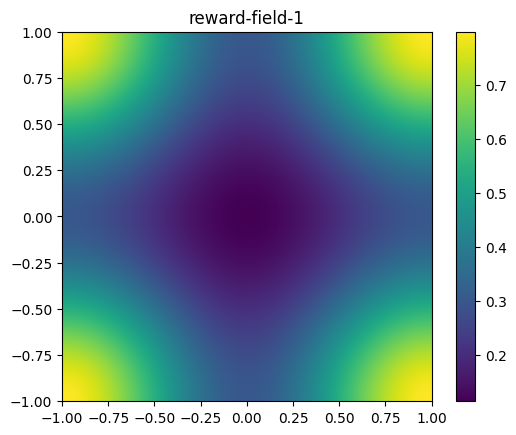

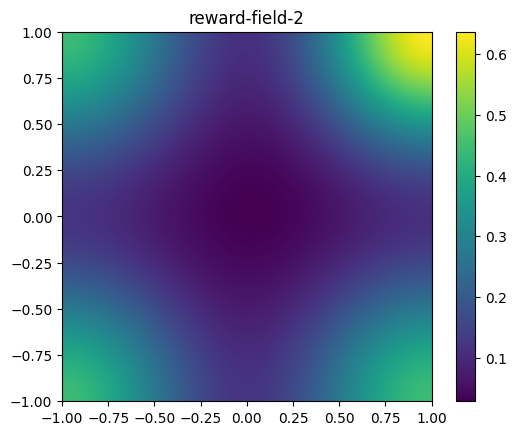

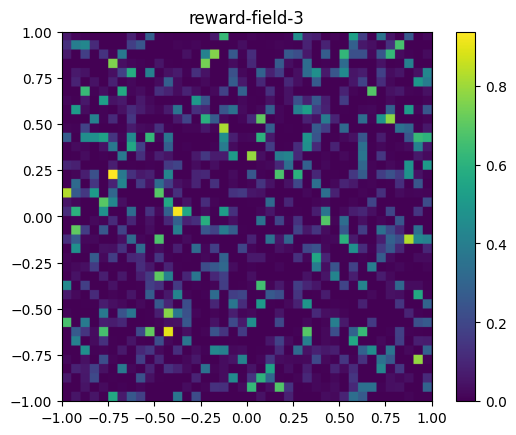

Tests passed.


<Figure size 640x480 with 0 Axes>

In [5]:
def visualize_fractal_problems():
  """Visualize the fractal problems with different rewards fields."""
  import matplotlib.pyplot as plt
  for name, problem in get_fractal_problems().items():
    plt.title(name)
    problem.visualize_reward_field(show=True)
    plt.clf()

visualize_fractal_problems()

print('Tests passed.')

## Path-cost Problem from Reward Problem


### Question
Implement the reduction from a reward problem to a path-cost problem **as in lecture**.

For reference, our solution is **31** line(s) of code.

In [6]:
def path_cost_problem_from_reward_problem(
    reward_problem: RewardProblem) -> PathCostProblem:
    """Reduce a reward maximization problem into a path search problem.

    You should take a close look that the class definition of `RewardProblem`,
    since they will be handy.
    Especially note that the horizon value is inclusive -- for a horizon value of $H$,
    the agent should be allowed to step exactly $H$ number of steps.

    Args:
        problem: a RewardProblem.

    Returns:
        A PathCostProblem
    """
    ConvertedState = collections.namedtuple("ConvertedState", ['og_state', 'steps_left'])
    class PathCostProblemFromReward(PathCostProblem):
        def __init__(self, initial: State, reward_problem: RewardProblem):
            # new state format: state, "steps remaining"
            super().__init__(ConvertedState(initial, reward_problem.horizon))
            self.reward_problem = reward_problem

        def actions(self, state: ConvertedState) -> Iterable[Action]:
           return self.reward_problem.actions(state.og_state)

        def step(self, state: ConvertedState, action: Action) -> State:
           return ConvertedState(self.reward_problem.step(state.og_state, action), state.steps_left - 1)

        def goal_test(self, state: ConvertedState) -> bool:
           return state.steps_left == 0

        def step_cost(self, state1: ConvertedState, action: Action, state2: ConvertedState) -> float:
           return self.reward_problem.rmax - self.reward_problem.reward(state1.og_state, action, state2.og_state)

    return PathCostProblemFromReward(reward_problem.initial, reward_problem)

### Tests

In [7]:
def path_reward_reduction_test(path_cost_problem_from_reward_problem,
                               loc,
                               horizon: int = 4):
  problem = GradientRewardFieldProblem(locs=[loc],
                                       covs=0.3,
                                       strengths=[1.],
                                       horizon=horizon)
  path_problem = path_cost_problem_from_reward_problem(problem)
  state_sequence, action_sequence, cost_sequence, num_steps = run_uniform_cost_search(
      path_problem, step_budget=100000)
  assert ((len(state_sequence) - 1) == len(action_sequence) ==
          len(cost_sequence) == horizon)
  assert np.all(np.sign(np.array(action_sequence)) == np.sign(
      loc)), f"Actions {action_sequence} does not move towards {loc}"
  cost_sequence = np.array(cost_sequence)
  assert np.all(cost_sequence <= problem.rmax), "Costs should not exceed Rmax"
  assert np.all(cost_sequence >= 0), "Costs should be positive"
  assert np.all(np.diff(cost_sequence) <= 0), "Costs should be decreasing"

path_reward_reduction_test(path_cost_problem_from_reward_problem, (1, 1), 2)

def path_reward_reduction_test(path_cost_problem_from_reward_problem,
                               loc,
                               horizon: int = 4):
  problem = GradientRewardFieldProblem(locs=[loc],
                                       covs=0.3,
                                       strengths=[1.],
                                       horizon=horizon)
  path_problem = path_cost_problem_from_reward_problem(problem)
  state_sequence, action_sequence, cost_sequence, num_steps = run_uniform_cost_search(
      path_problem, step_budget=100000)
  assert ((len(state_sequence) - 1) == len(action_sequence) ==
          len(cost_sequence) == horizon)
  assert np.all(np.sign(np.array(action_sequence)) == np.sign(
      loc)), f"Actions {action_sequence} does not move towards {loc}"
  cost_sequence = np.array(cost_sequence)
  assert np.all(cost_sequence <= problem.rmax), "Costs should not exceed Rmax"
  assert np.all(cost_sequence >= 0), "Costs should be positive"
  assert np.all(np.diff(cost_sequence) <= 0), "Costs should be decreasing"

path_reward_reduction_test(path_cost_problem_from_reward_problem, (1, 1), 3)

def path_reward_reduction_test(path_cost_problem_from_reward_problem,
                               loc,
                               horizon: int = 4):
  problem = GradientRewardFieldProblem(locs=[loc],
                                       covs=0.3,
                                       strengths=[1.],
                                       horizon=horizon)
  path_problem = path_cost_problem_from_reward_problem(problem)
  state_sequence, action_sequence, cost_sequence, num_steps = run_uniform_cost_search(
      path_problem, step_budget=100000)
  assert ((len(state_sequence) - 1) == len(action_sequence) ==
          len(cost_sequence) == horizon)
  assert np.all(np.sign(np.array(action_sequence)) == np.sign(
      loc)), f"Actions {action_sequence} does not move towards {loc}"
  cost_sequence = np.array(cost_sequence)
  assert np.all(cost_sequence <= problem.rmax), "Costs should not exceed Rmax"
  assert np.all(cost_sequence >= 0), "Costs should be positive"
  assert np.all(np.diff(cost_sequence) <= 0), "Costs should be decreasing"

path_reward_reduction_test(path_cost_problem_from_reward_problem, (1, 1), 5)

def path_reward_reduction_test(path_cost_problem_from_reward_problem,
                               loc,
                               horizon: int = 4):
  problem = GradientRewardFieldProblem(locs=[loc],
                                       covs=0.3,
                                       strengths=[1.],
                                       horizon=horizon)
  path_problem = path_cost_problem_from_reward_problem(problem)
  state_sequence, action_sequence, cost_sequence, num_steps = run_uniform_cost_search(
      path_problem, step_budget=100000)
  assert ((len(state_sequence) - 1) == len(action_sequence) ==
          len(cost_sequence) == horizon)
  assert np.all(np.sign(np.array(action_sequence)) == np.sign(
      loc)), f"Actions {action_sequence} does not move towards {loc}"
  cost_sequence = np.array(cost_sequence)
  assert np.all(cost_sequence <= problem.rmax), "Costs should not exceed Rmax"
  assert np.all(cost_sequence >= 0), "Costs should be positive"
  assert np.all(np.diff(cost_sequence) <= 0), "Costs should be decreasing"

path_reward_reduction_test(path_cost_problem_from_reward_problem, (-1, -1), 2)

def path_reward_reduction_test(path_cost_problem_from_reward_problem,
                               loc,
                               horizon: int = 4):
  problem = GradientRewardFieldProblem(locs=[loc],
                                       covs=0.3,
                                       strengths=[1.],
                                       horizon=horizon)
  path_problem = path_cost_problem_from_reward_problem(problem)
  state_sequence, action_sequence, cost_sequence, num_steps = run_uniform_cost_search(
      path_problem, step_budget=100000)
  assert ((len(state_sequence) - 1) == len(action_sequence) ==
          len(cost_sequence) == horizon)
  assert np.all(np.sign(np.array(action_sequence)) == np.sign(
      loc)), f"Actions {action_sequence} does not move towards {loc}"
  cost_sequence = np.array(cost_sequence)
  assert np.all(cost_sequence <= problem.rmax), "Costs should not exceed Rmax"
  assert np.all(cost_sequence >= 0), "Costs should be positive"
  assert np.all(np.diff(cost_sequence) <= 0), "Costs should be decreasing"

path_reward_reduction_test(path_cost_problem_from_reward_problem, (-1, -1), 3)

def path_reward_reduction_test(path_cost_problem_from_reward_problem,
                               loc,
                               horizon: int = 4):
  problem = GradientRewardFieldProblem(locs=[loc],
                                       covs=0.3,
                                       strengths=[1.],
                                       horizon=horizon)
  path_problem = path_cost_problem_from_reward_problem(problem)
  state_sequence, action_sequence, cost_sequence, num_steps = run_uniform_cost_search(
      path_problem, step_budget=100000)
  assert ((len(state_sequence) - 1) == len(action_sequence) ==
          len(cost_sequence) == horizon)
  assert np.all(np.sign(np.array(action_sequence)) == np.sign(
      loc)), f"Actions {action_sequence} does not move towards {loc}"
  cost_sequence = np.array(cost_sequence)
  assert np.all(cost_sequence <= problem.rmax), "Costs should not exceed Rmax"
  assert np.all(cost_sequence >= 0), "Costs should be positive"
  assert np.all(np.diff(cost_sequence) <= 0), "Costs should be decreasing"

path_reward_reduction_test(path_cost_problem_from_reward_problem, (-1, -1), 5)
print('Tests passed.')

Tests passed.


In [8]:
asymetric_problem = get_fractal_problems()['reward-field-2']
asym_cost_problem = path_cost_problem_from_reward_problem(asymetric_problem)

state_sequence, action_sequence, cost_sequence, num_steps = run_uniform_cost_search(
      asym_cost_problem, step_budget=100000)

In [9]:
state_sequence

[ConvertedState(og_state=FractalProblemState(x=0, y=0, t=1), steps_left=6),
 ConvertedState(og_state=FractalProblemState(x=0.5, y=0.5, t=2), steps_left=5),
 ConvertedState(og_state=FractalProblemState(x=0.75, y=0.75, t=3), steps_left=4),
 ConvertedState(og_state=FractalProblemState(x=0.875, y=0.875, t=4), steps_left=3),
 ConvertedState(og_state=FractalProblemState(x=0.9375, y=0.9375, t=5), steps_left=2),
 ConvertedState(og_state=FractalProblemState(x=0.96875, y=0.96875, t=6), steps_left=1),
 ConvertedState(og_state=FractalProblemState(x=0.984375, y=0.984375, t=7), steps_left=0)]

## MCTS vs. UCS


### Utilities

Our implementation of MCTS.
**Note**: these imports and functions are available in catsoop. You do not need to copy them in.

In [10]:

import dataclasses


@dataclasses.dataclass(frozen=False, eq=False)
class MCTNode:
  """Node in the Monte Carlo search tree, keeps track of the children states."""
  state: State
  U: float
  N: int
  horizon: int
  parent: Optional['MCTNode']
  children: Dict['MCTNode', Action] = dataclasses.field(default_factory=dict)


def ucb(n: MCTNode, C: float = 1.4) -> float:
  """UCB for a node, note the C argument"""
  return np.inf if n.N == 0 else (n.U / n.N +
                                  C * np.sqrt(np.log(n.parent.N) / n.N))


def run_mcts_search(problem: RewardProblem,
                    C: float = 1.4,
                    iteration_budget: int = 1000,
                    step_budget: int = np.inf):
  """A generic MCTS search implementation.

  Args:
    problem: a reward problem.
    C: the UCB parameter.
    iteration_budget: maximum iterations to run the search.
    step_budget: maximum number of allowed `problem.step`s.

  Returns:
    state_sequence: A list of states.
    action_sequence: A list of actions.
    reward_sequence: A list of rewards
  """
  if min(iteration_budget, step_budget) == np.inf:
    raise ValueError("Must provide at least one budget")

  problem_step_count = 0

  class BudgetExceeded(Exception):
    pass

  def step_helper(state, action):
    """helper to track the problem's step count."""
    nonlocal problem_step_count
    problem_step_count += 1
    if problem_step_count > step_budget:
      raise BudgetExceeded("step budget exceeded")
    return problem.step(state, action)

  ucb_fixed_C = functools.partial(ucb, C=C)

  def select(n: MCTNode) -> MCTNode:
    """select a leaf node in the tree"""
    if n.children:
      ucb_pick = max(n.children.keys(), key=ucb_fixed_C)
      return select(ucb_pick)
    return n

  def expand(n: MCTNode) -> MCTNode:
    """expand the leaf node by adding all its children states"""
    assert not n.children
    if n.horizon == 0:
      return n
    for action in problem.actions(n.state):
      child_state = step_helper(n.state, action)
      new_node = MCTNode(state=child_state,
                         horizon=n.horizon - 1,
                         parent=n,
                         U=0,
                         N=0)
      n.children[new_node] = action
    child = random.choice(list(n.children.keys()))
    return child

  def simulate(node: MCTNode) -> float:
    """simulate the utility of current state by randomly picking a step"""
    state = node.state
    total_reward = 0
    for h in range(node.horizon, 0, -1):
      action = random.choice(problem.actions(state))
      child_state = step_helper(state, action)
      reward = problem.reward(state, action, child_state)
      total_reward += reward
      state = child_state
    return total_reward

  def backup(n: MCTNode, value: float) -> None:
    """passing the utility back to all parent nodes"""
    if n.parent:
      # Need to include the reward on the action *into* n
      a = n.parent.children[n]
      r = problem.reward(n.parent.state, a, n.state)
      n.U += value + r
      n.N += 1
      backup(n.parent, value + r)
    else:
      n.N += 1

  root = MCTNode(state=problem.initial,
                 horizon=problem.horizon,
                 parent=None,
                 U=0,
                 N=0)

  try:
    i = 0
    while i < iteration_budget:
      leaf = select(root)
      child = expand(leaf)
      value = simulate(child)
      backup(child, value)
      i += 1
  except BudgetExceeded:
    pass

  return finish_mcts_plan(problem, root)


def finish_mcts_plan(problem: RewardProblem, node: MCTNode):
  """Helper for run_mcts_search. Recover the plan. """
  state_sequence = [node.state]
  action_sequence = []
  reward_sequence = []

  while node.children:
    max_node = max(node.children, key=lambda p: p.N)
    max_action = node.children.get(max_node)
    action_sequence.append(max_action)
    state_sequence.append(max_node.state)
    reward_sequence.append(
        problem.reward(node.state, max_action, max_node.state))
    node = max_node

  return state_sequence, action_sequence, reward_sequence

### Tests

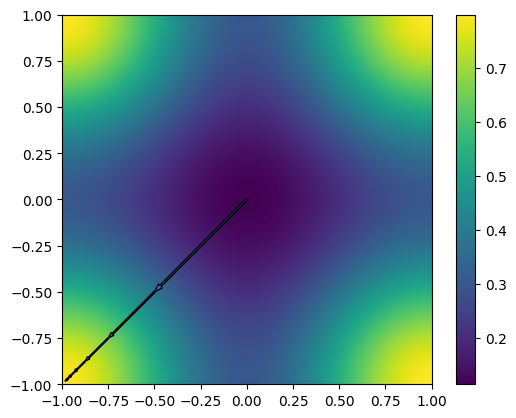

Tests passed.


In [11]:
def visualize_mcts():
  """Solve one of the fractal problems and visualize the plan.

  This function may take a few moments to run.
  """
  # You may change this to visualize other reward fields.
  problem = get_fractal_problems()["reward-field-1"]

  plan = run_mcts_search(problem, iteration_budget=10000)
  problem.visualize_reward_field().visualize_plan(plan[0], show=True)

visualize_mcts()

print('Tests passed.')

### Compare the Performance

In [12]:
problems = get_fractal_problems()
for name, problem in problems.items():
    # Run MCTS
    mcts_rewards = []
    for _ in range(20):
        plan = run_mcts_search(problem, iteration_budget=np.inf, step_budget=2500)
        mcts_rewards.append(sum(plan[2]))

    # Run UCS
    try:
        ucs_plan = run_uniform_cost_search(
            path_cost_problem_from_reward_problem(problem), step_budget=2500
        )
        ucs_reward = 0
        for r in ucs_plan[2]:
            ucs_reward += problem.rmax - r
        ucs_plan_length = len(ucs_plan[0]) - 1
    except SearchFailed:
        ucs_reward = 0
        ucs_plan_length = None

    print(f"Problem: {name}")
    print(f"MCTS Average Reward: {np.mean(mcts_rewards)}")
    print(f"UCS Reward: {ucs_reward}")
    print(f"UCS Steps: {ucs_plan_length}")

Problem: reward-field-1
MCTS Average Reward: 4.155821535914783
UCS Reward: 0
UCS Steps: None
Problem: reward-field-2
MCTS Average Reward: 3.1132904170556404
UCS Reward: 0
UCS Steps: None
Problem: reward-field-3
MCTS Average Reward: 1.0250132879350893
UCS Reward: 3.1911534984544563
UCS Steps: 6


# PDDL

## Let's Make a Plan


### Imports and Utilties
**Note**: these imports and functions are available in catsoop. You do not need to copy them in.

In [13]:
import os
import time
import tempfile
from pyperplan.pddl.parser import Parser
from pyperplan import grounding, planner

# This uses TYPING
BLOCKS_DOMAIN = """(define (domain blocks)
    (:requirements :strips :typing)
    (:types block)
    (:predicates
        (on ?x - block ?y - block)
        (ontable ?x - block)
        (clear ?x - block)
        (handempty)
        (holding ?x - block)
    )

    (:action pick-up
        :parameters (?x - block)
        :precondition (and
            (clear ?x)
            (ontable ?x)
            (handempty)
        )
        :effect (and
            (not (ontable ?x))
            (not (clear ?x))
            (not (handempty))
            (holding ?x)
        )
    )

    (:action put-down
        :parameters (?x - block)
        :precondition (and
            (holding ?x)
        )
        :effect (and
            (not (holding ?x))
            (clear ?x)
            (handempty)
            (ontable ?x))
        )

    (:action stack
        :parameters (?x - block ?y - block)
        :precondition (and
            (holding ?x)
            (clear ?y)
        )
        :effect (and
            (not (holding ?x))
            (not (clear ?y))
            (clear ?x)
            (handempty)
            (on ?x ?y)
        )
    )

    (:action unstack
        :parameters (?x - block ?y - block)
        :precondition (and
            (on ?x ?y)
            (clear ?x)
            (handempty)
        )
        :effect (and
            (holding ?x)
            (clear ?y)
            (not (clear ?x))
            (not (handempty))
            (not (on ?x ?y))
        )
    )
)
"""

# This uses TYPING
BLOCKS_PROBLEM = """(define (problem blocks)
    (:domain blocks)
    (:objects
        d - block
        b - block
        a - block
        c - block
    )
    (:init
        (clear a)
        (on a b)
        (on b c)
        (on c d)
        (ontable d)
        (handempty)
    )
    (:goal (and (on d c) (on c b) (on b a)))
)
"""

# The BW domain does not use TYPING
BW_BLOCKS_DOMAIN = """(define (domain prodigy-bw)
  (:requirements :strips)
  (:predicates (on ?x ?y)
               (ontable ?x)
               (clear ?x)
               (handempty)
               (holding ?x)
               )
  (:action pick-up
             :parameters (?ob1)
             :precondition (and (clear ?ob1) (ontable ?ob1) (handempty))
             :effect
             (and (not (ontable ?ob1))
                   (not (clear ?ob1))
                   (not (handempty))
                   (holding ?ob1)))
  (:action put-down
             :parameters (?ob)
             :precondition (holding ?ob)
             :effect
             (and (not (holding ?ob))
                   (clear ?ob)
                   (handempty)
                   (ontable ?ob)))
  (:action stack
             :parameters (?sob ?sunderob)
             :precondition (and (holding ?sob) (clear ?sunderob))
             :effect
             (and (not (holding ?sob))
                   (not (clear ?sunderob))
                   (clear ?sob)
                   (handempty)
                   (on ?sob ?sunderob)))
  (:action unstack
             :parameters (?sob ?sunderob)
             :precondition (and (on ?sob ?sunderob) (clear ?sob) (handempty))
             :effect
             (and (holding ?sob)
                   (clear ?sunderob)
                   (not (clear ?sob))
                   (not (handempty))
                   (not (on ?sob ?sunderob)))))
"""


def get_task_definition_str(domain_pddl_str, problem_pddl_str):
    """Get Pyperplan task definition from PDDL domain and problem.

    This function is a lightweight wrapper around Pyperplan.

    Args:
      domain_pddl_str: A str, the contents of a domain.pddl file.
      problem_pddl_str: A str, the contents of a problem.pddl file.

    Returns:
      task: a structure defining the problem
    """
    # Parsing the PDDL
    domain_file = tempfile.NamedTemporaryFile(delete=False)
    problem_file = tempfile.NamedTemporaryFile(delete=False)
    with open(domain_file.name, 'w') as f:
        f.write(domain_pddl_str)
    with open(problem_file.name, 'w') as f:
        f.write(problem_pddl_str)
    parser = Parser(domain_file.name, problem_file.name)
    domain = parser.parse_domain()
    problem = parser.parse_problem(domain)
    os.remove(domain_file.name)
    os.remove(problem_file.name)

    # Ground the PDDL
    task = grounding.ground(problem)
    return task


def run_planning(domain_pddl_str,
                 problem_pddl_str,
                 search_alg_name,
                 heuristic_name=None,
                 return_time=False):
    """Plan a sequence of actions to solve the given PDDL problem.

    This function is a lightweight wrapper around pyperplan.

    Args:
      domain_pddl_str: A str, the contents of a domain.pddl file.
      problem_pddl_str: A str, the contents of a problem.pddl file.
      search_alg_name: A str, the name of a search algorithm in
        pyperplan. Options: astar, wastar, gbf, bfs, ehs, ids, sat.
      heuristic_name: A str, the name of a heuristic in pyperplan.
        Options: blind, hadd, hmax, hsa, hff, lmcut, landmark.
      return_time:  Bool. Set to `True` to return the planning time.

    Returns:
      plan: A list of actions; each action is a pyperplan Operator.
    """
    # Ground the PDDL
    task = get_task_definition_str(domain_pddl_str, problem_pddl_str)

    # Get the search alg
    search_alg = planner.SEARCHES[search_alg_name]

    if heuristic_name is None:
        if not return_time:
            return search_alg(task)
        start_time = time.time()
        plan = search_alg(task)
        plan_time = time.time() - start_time
        return plan, plan_time

    # Get the heuristic
    heuristic = planner.HEURISTICS[heuristic_name](task)

    # Run planning
    start_time = time.time()
    plan = search_alg(task, heuristic)
    plan_time = time.time() - start_time

    if return_time:
        return plan, plan_time
    return plan


def h_add_test(prob_str, expected_h):
    task = get_task_definition_str(BW_BLOCKS_DOMAIN, prob_str)
    h = h_add(task)
    assert h == expected_h, f"Expected h={expected_h}, but got {h}."
    return h


def h_ff_test(prob_str, expected_h):
    task = get_task_definition_str(BW_BLOCKS_DOMAIN, prob_str)
    h = h_ff(task)
    assert h == expected_h, f"Expected h={expected_h}, but got {h}."

### Question
Use `run_planning` to find a plan for the blocks problem defined at the top of the colab file (`BLOCKS_DOMAIN`, `BLOCKS_PROBLEM`).

  The `run_planning` function takes in a PDDL domain string, a PDDL problem string, the name of a search algorithm, and the name of a heuristic (if the search algorithm is informed) or a customized heuristic class. It then uses the Python planning library `pyperplan` to find a plan.

  The plan returned by `run_planning` is a list of pyperplan Operators. You should not need to manipulate these data structures directly in this homework, but if you are curious about the definition, see [here](https://github.com/aibasel/pyperplan/blob/master/pyperplan/task.py#L23).

  The search algs available in pyperplan are: `astar, wastar, gbf, bfs, ehs, ids, sat`. The heuristics available in pyperplan are: `blind, hadd, hmax, hsa, hff, lmcut, landmark`.

  For this question, use the `astar` search algorithm with the `hadd` heuristic.

For reference, our solution is **2** line(s) of code.

In [16]:
def planning_warmup():
    '''Use run_planning to find a plan for the blocks problem defined at the
    top of the colab file (BLOCKS_DOMAIN, BLOCKS_PROBLEM).

      Use the astar search algorithm with the hadd heuristic.

    Returns:
      plan: A list of actions; each action is a pyperplan Operator.
    '''
    return run_planning(BLOCKS_DOMAIN, BLOCKS_PROBLEM, 'astar', 'hadd')

### Tests

In [17]:
def warmup_test1():
    plan = planning_warmup()
    assert len(plan) == 8
    assert plan[0].name == '(unstack a b)'

warmup_test1()

print('Tests passed.')

Tests passed.


## Fill in the Blanks


### Question
You've received PDDL domain and problem strings from your boss and you need to make a plan, pronto! Unfortunately, some of the PDDL is missing.

  Here's what you know. What you're trying to model is a newspaper delivery robot. The robot starts out at a "home base" where there are papers that it can pick up. The robot can hold arbitrarily many papers at once. It can then move around to different locations and deliver papers.

  Not all locations want a paper -- the goal is to satisfy all the locations that do want a paper.

  You also know:
  * There are 6 locations in addition to 1 for the homebase. Locations 1, 2, 3, and 4 want paper; locations 5 and 6 do not.
  * There are 8 papers at the homebase.
  * The robot is initially at the homebase with no papers packed.

  Use this description to complete the PDDL domain and problem. You can assume the PDDL planner will find the optimal solution.

  If you are running into issues writing or debugging the PDDL you can check out this online PDDL editor, which comes with a built-in planner: [editor.planning.domains](http://editor.planning.domains). To use the editor, you can create two files, one for the domain and one for the problem. You can then click "Solve" at the top to use the built-in planner.

For a general reference on PDDL, check out [planning.wiki](https://planning.wiki/). Note that the PDDL features supported by pyperplan are very limited: types and constants are supported, but that's about it. If you want to make a domain that involves more advanced features, you can try the built-in planner at [editor.planning.domains](http://editor.planning.domains), or you can use any other PDDL planner of your choosing.

Debugging PDDL can be painful. The online editor at [editor.planning.domains](http://editor.planning.domains) is helpful: pay attention to the syntax highlighting and to the line numbers in error messages that result from trying to Solve. To debug, you can also comment out multiple lines of your files by highlighting and using command+/. Common issues to watch out for include:
* A predicate is not defined in the domain file
* A variable name does not start with a question mark
* An illegal character is used (we recommended sticking with alphanumeric characters, dashes, or underscores; and don't start any names with numbers)
* An operator is missing a parameter (in general, the parameters should be exactly the variables that are used anywhere in the operator's preconditions or effects)
* An operator is missing a necessary precondition or effect
* Using negated preconditions, which are not allowed in basic Strips

If you get stuck debugging your PDDL file for more than 10-15 min, please reach out and we'll help!

  

For reference, our solution is **89** line(s) of code.

In [20]:
def pddl_warmup():
    '''Creates a PDDL domain and problem strs for newspaper delivery (uses
    TYPING).

    Returns:
      domain: str
      problem: str
    '''
    domain_str = '''(define (domain newspapers)
    (:requirements :strips :typing)
    (:types loc paper)
    (:predicates
      (isHomeBase ?loc - loc)
      (satisfied ?loc - loc)
      (at ?loc - loc)
      (unpacked ?paper - paper)
      (carrying ?paper - paper)
    )

    (:action pick-up
      :parameters (?loc - loc ?paper - paper)
      :precondition (and
        (at ?loc)
        (isHomeBase ?loc)
        (unpacked ?paper)
      )
      :effect (and
        (not (unpacked ?paper))
        (carrying ?paper)
      )
    )

    (:action move
      :parameters (?from - loc ?to - loc)
      :precondition (and
        (at ?from)
      )
      :effect (and
        (not (at ?from))
        (at ?to)
      )
    )

    (:action deliver
      :parameters (?paper - paper ?loc - loc)
      :precondition (and
        (carrying ?paper)
        (at ?loc)
      )
      :effect (and
        (not (carrying ?paper))
        (satisfied ?loc)
      )
    )

)'''

    problem_str = '''(define (problem newspapers1) (:domain newspapers)
  (:objects
    loc-0 - loc
    loc-1 - loc
    loc-2 - loc
    loc-3 - loc
    loc-4 - loc
    loc-5 - loc
    loc-6 - loc
    paper-0 - paper
    paper-1 - paper
    paper-2 - paper
    paper-3 - paper
    paper-4 - paper
    paper-5 - paper
    paper-6 - paper
    paper-7 - paper
  )
  (:init
    (at loc-0)
    (isHomeBase loc-0)
    (unpacked paper-0)
    (unpacked paper-1)
    (unpacked paper-2)
    (unpacked paper-3)
    (unpacked paper-4)
    (unpacked paper-5)
    (unpacked paper-6)
    (unpacked paper-7)
  )
  (:goal (and
    (satisfied loc-1)
    (satisfied loc-2)
    (satisfied loc-3)
    (satisfied loc-4)
  ))
)'''

    return domain_str, problem_str

### Tests

In [21]:
def warmup_test2():
    domain, problem = pddl_warmup()
    plan = run_planning(domain, problem, "gbf", "hadd")
    assert plan, "Failed to find a plan."
    picked_up_papers = set()
    satisfied_locs = set()
    for op in plan:
        if "pickup" in op.name:
            _, _, paper, _ = op.name.split(" ")
            assert paper not in picked_up_papers, \
                "Should not pick up the same paper twice"
            picked_up_papers.add(paper)
        elif "deliver" in op.name:
            _, loc = op.name.rsplit(" ", 1)
            assert loc.endswith(")")
            loc = loc[:-1]
            assert loc not in satisfied_locs, \
                "Should not deliver to the same place twice"
            satisfied_locs.add(loc)
    assert satisfied_locs == {"loc-1", "loc-2", "loc-3", "loc-4"}

warmup_test2()

print('Tests passed.')

Tests passed.


## Heuristics Comparision


### Heuristics Comparison Utilities
**Note**: these imports and functions are available in catsoop. You do not need to copy them in.

In [22]:
BW_BLOCKS_PROBLEM_1 = """(define (problem bw-simple)
  (:domain prodigy-bw)
  (:objects A B C)
  (:init (clear a) (handempty) (on a b) (ontable b))
  (:goal (and (ontable a) (clear b))))
"""

BW_BLOCKS_PROBLEM_2 = """(define (problem bw-sussman)
  (:domain prodigy-bw)
  (:objects A B C)
  (:init (ontable a) (ontable b) (on c a)
                (clear b) (clear c) (handempty))
  (:goal (and (on a b) (on b c))))
"""

BW_BLOCKS_PROBLEM_3 = """(define (problem bw-large-a)
  (:domain prodigy-bw)
  (:objects 1 2 3 4 5 6 7 8 9)
  (:init (handempty)
         (on 3 2)
         (on 2 1)
         (ontable 1)
         (on 5 4)
         (ontable 4)
         (on 9 8)
         (on 8 7)
         (on 7 6)
         (ontable 6)
         (clear 3)
         (clear 5)
         (clear 9))
  (:goal (and
          (on 1 5)
          (ontable 5)
          (on 8 9)
          (on 9 4)
          (ontable 4)
          (on 2 3)
          (on 3 7)
          (on 7 6)
          (ontable 6)
          (clear 1)
          (clear 8)
          (clear 2)
          )))
"""

BW_BLOCKS_PROBLEM_4 = """(define (problem bw-large-b)
  (:domain prodigy-bw)
  (:objects 1 2 3 4 5 6 7 8 9 10 11)
  (:init (handempty)
         (on 3 2)
         (on 2 1)
         (ontable 1)
         (on 11 10)
         (on 10 5)
         (on 5 4)
         (ontable 4)
         (on 9 8)
         (on 8 7)
         (on 7 6)
         (ontable 6)
         (clear 3)
         (clear 11)
         (clear 9))
  (:goal (and
          (on 1 5)
          (on 5 10)
          (ontable 10)
          (on 8 9)
          (on 9 4)
          (ontable 4)
          (on 2 3)
          (on 3 11)
          (on 11 7)
          (on 7 6)
          (ontable 6)
          (clear 1)
          (clear 8)
          (clear 2)
          )))
"""

BW_BLOCKS_PROBLEM_5 = """(define (problem bw-large-c)
  (:domain prodigy-bw)
  (:objects 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15)
  (:init (handempty)
         (on 3 2)
         (on 2 1)
         (on 1 12)
         (on 12 13)
         (ontable 13)
         (on 11 10)
         (on 10 5)
         (on 5 4)
         (on 4 14)
         (on 14 15)
         (ontable 15)
         (on 9 8)
         (on 8 7)
         (on 7 6)
         (ontable 6)
         (clear 3)
         (clear 11)
         (clear 9))
  (:goal (and
          (on 14 1)
          (on 1 5)
          (on 5 10)
          (ontable 10)
          (on 15 13)
          (on 13 8)
          (on 8 9)
          (on 9 4)
          (ontable 4)
          (on 12 2)
          (on 2 3)
          (on 3 11)
          (on 11 7)
          (on 7 6)
          (ontable 6)
          (clear 14)
          (clear 15)
          (clear 12)
          )))

"""

BW_BLOCKS_PROBLEM_6 = """(define (problem bw-large-d)
  (:domain prodigy-bw)
  (:objects 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19)
  (:init (handempty)
         (on 1 12)
         (on 12 13)
         (ontable 13)
         (on 11 10)
         (on 10 5)
         (on 5 4)
         (on 4 14)
         (on 14 15)
         (ontable 15)
         (on 9 8)
         (on 8 7)
         (on 7 6)
         (ontable 6)
         (on 19 18)
         (on 18 17)
         (on 17 16)
         (on 16 3)
         (on 3 2)
         (ontable 2)
         (clear 1)
         (clear 11)
         (clear 9)
         (clear 19))
  (:goal (and
          (on 17 18)
          (on 18 19)
          (on 19 14)
          (on 14 1)
          (on 1 5)
          (on 5 10)
          (ontable 10)
          (on 15 13)
          (on 13 8)
          (on 8 9)
          (on 9 4)
          (ontable 4)
          (on 12 2)
          (on 2 3)
          (on 3 16)
          (on 16 11)
          (on 11 7)
          (on 7 6)
          (ontable 6)
          (clear 17)
          (clear 15)
          (clear 12)
          )))
"""
BW_BLOCKS_PROBLEMS = [
    BW_BLOCKS_PROBLEM_1, BW_BLOCKS_PROBLEM_2, BW_BLOCKS_PROBLEM_3,
    BW_BLOCKS_PROBLEM_4, BW_BLOCKS_PROBLEM_5, BW_BLOCKS_PROBLEM_6
]

### Question
We have created some helper functions to plot the running time and plan length of certain search algorithms and heuristics.
    You can use the `test_all_combinations` function in the following code block to get the planning results.

In [23]:
import itertools, sys, logging, importlib


def test_run_planning(domain_pddl_str,
                      problem_pddl_id,
                      search_alg_name,
                      heuristic_name,
                      save_dict=None):
    plan, run_time = run_planning(domain_pddl_str,
                                  BW_BLOCKS_PROBLEMS[problem_pddl_id - 1],
                                  search_alg_name,
                                  heuristic_name,
                                  return_time=True)
    print(f'Run time\t {run_time:.4f}\t Plan length\t {len(plan)}')
    save_dict[(search_alg_name, heuristic_name,
               problem_pddl_id)] = [run_time, len(plan)]
    return len(plan), run_time


def plot_result(result, timeout):
    import matplotlib.pyplot as plt
    all_problem_keys = result.keys()
    for problem_id in range(1, 7):
        problem_keys = [k for k in all_problem_keys if k[2] == problem_id]
        problem_keys_str = list(map(lambda x: f'{x[0]}-{x[1]}', problem_keys))
        bb = [
            result[k][0] if result[k][0] != -1 else timeout
            for k in problem_keys
        ]
        cc = [result[k][1] if result[k][0] != -1 else 0 for k in problem_keys]
        fig, axes = plt.subplots(figsize=(10, 6), ncols=2, sharey=True)
        axes[0].barh(problem_keys_str, bb, align='center', color='y')
        axes[1].barh(problem_keys_str, cc, align='center', color='g')
        axes[0].invert_xaxis()
        plt.subplots_adjust(wspace=0)

        axes[0].set(title='Planning time')
        axes[1].set(title='Plan length')
        fig.suptitle(f'Problem-{problem_id}')
        plt.show()


def test_all_combinations(timeout=5):
    import multiprocess as mp
    importlib.reload(logging)
    logging.basicConfig(level=logging.INFO,
                        handlers=[logging.StreamHandler(sys.stdout)])
    problem_id = [i for i in range(1, 7)]
    all_searchalgs = ['gbf', 'astar']
    all_heuristics = ['blind', 'hmax', 'hadd', 'hff', 'lmcut']
    result = {
        (j, k, i): [-1, -1]
        for (i, j,
             k) in itertools.product(problem_id, all_searchalgs, all_heuristics)
    }
    result_savers = []
    with mp.Manager() as manager:
        for problem_i, search_algo, heuristic in itertools.product(
                problem_id, all_searchalgs, all_heuristics):
            print(f'problem_{problem_i}', search_algo, heuristic)
            result_saver = manager.dict()
            result_savers.append(result_saver)
            planning_proc = mp.Process(target=test_run_planning,
                                       args=(BW_BLOCKS_DOMAIN, problem_i,
                                             search_algo, heuristic,
                                             result_saver))
            planning_proc.start()
            planning_proc.join(timeout=timeout)
            if planning_proc.is_alive():
                planning_proc.terminate()
                print(f'Terminate after {timeout} sec.')
                print()
                continue
            print()
        for res in result_savers:
            result.update(res)
    plot_result(result, timeout)

importlib.reload(logging)

<module 'logging' from '/usr/lib/python3.12/logging/__init__.py'>

problem_1 gbf blind
INFO:root:Relevance analysis removed 0 facts
INFO:root:Initial h value: 1.000000
INFO:root:Goal reached. Start extraction of solution.
INFO:root:3 Nodes expanded
Run time	 0.0154	 Plan length	 2

problem_1 gbf hmax
INFO:root:Relevance analysis removed 0 facts
INFO:root:Initial h value: 2.000000
INFO:root:Goal reached. Start extraction of solution.
INFO:root:3 Nodes expanded
Run time	 0.0169	 Plan length	 2

problem_1 gbf hadd
INFO:root:Relevance analysis removed 0 facts
INFO:root:Initial h value: 3.000000
INFO:root:Goal reached. Start extraction of solution.
INFO:root:3 Nodes expanded
Run time	 0.0237	 Plan length	 2

problem_1 gbf hff
INFO:root:Relevance analysis removed 0 facts
INFO:root:Initial h value: 2.000000
INFO:root:Goal reached. Start extraction of solution.
INFO:root:3 Nodes expanded
Run time	 0.0125	 Plan length	 2

problem_1 gbf lmcut
INFO:root:Relevance analysis removed 0 facts
INFO:root:Initial h value: 2.000000
INFO:root:Goal reached. Start extractio

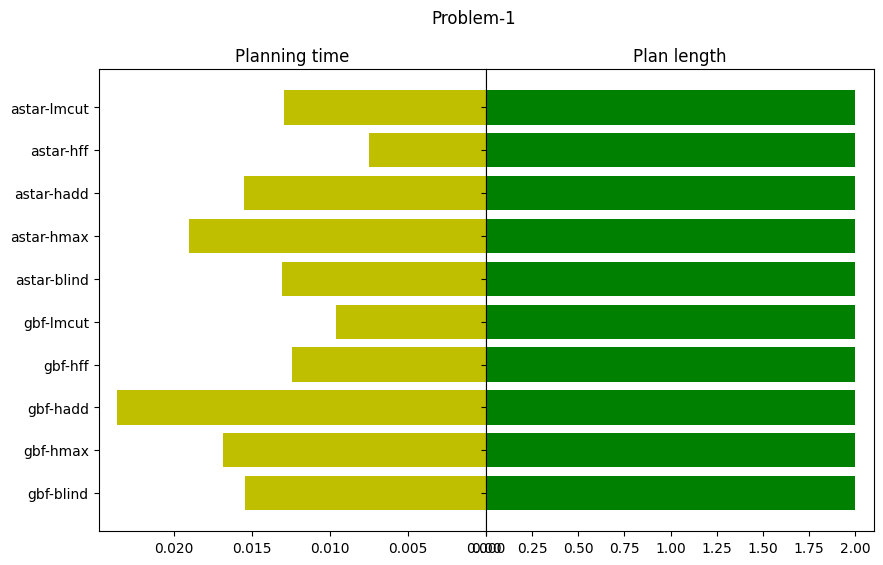

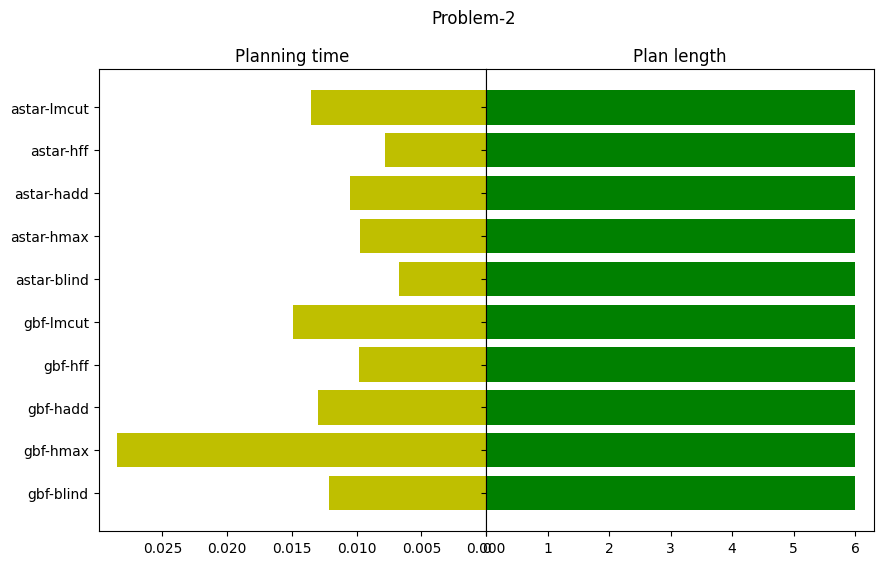

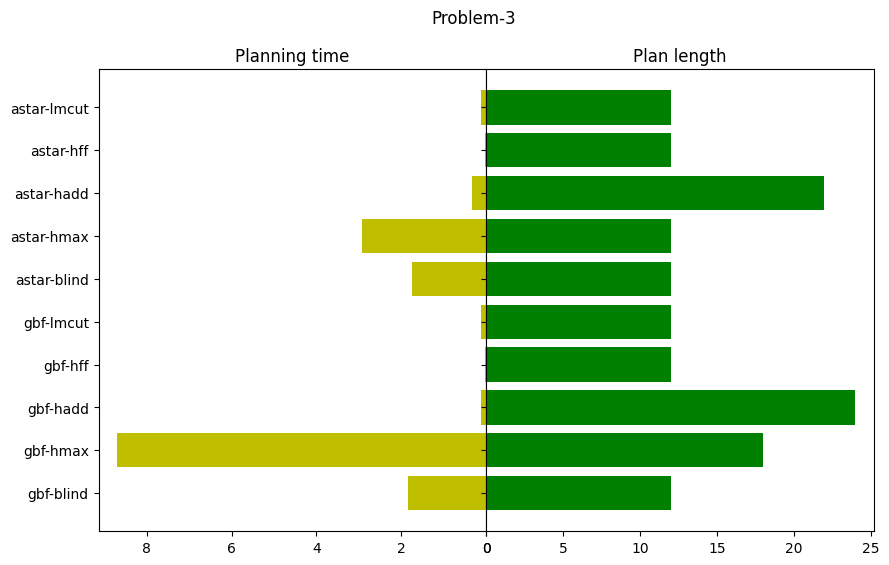

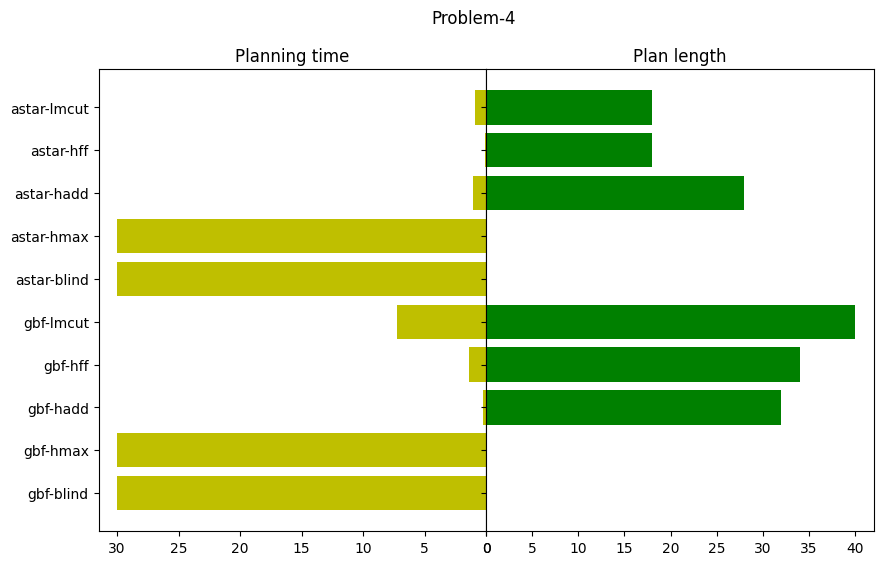

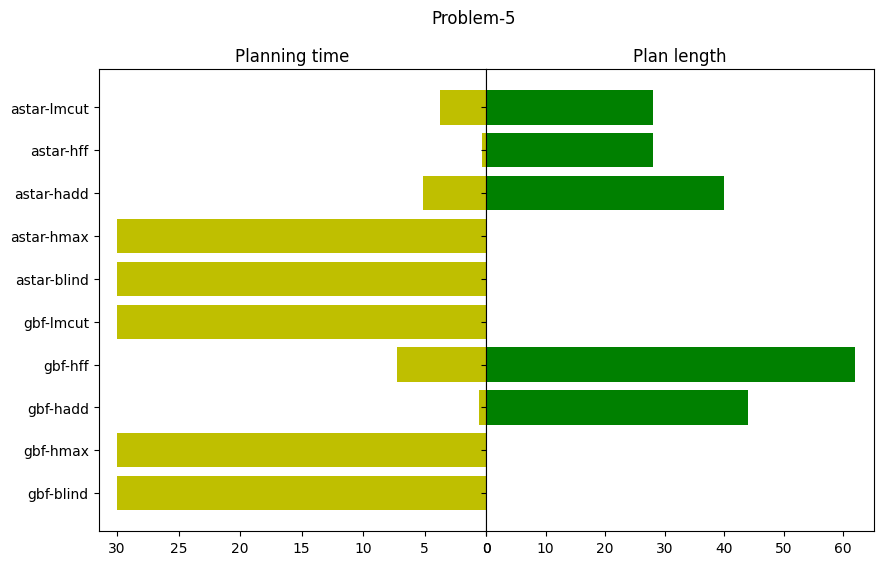

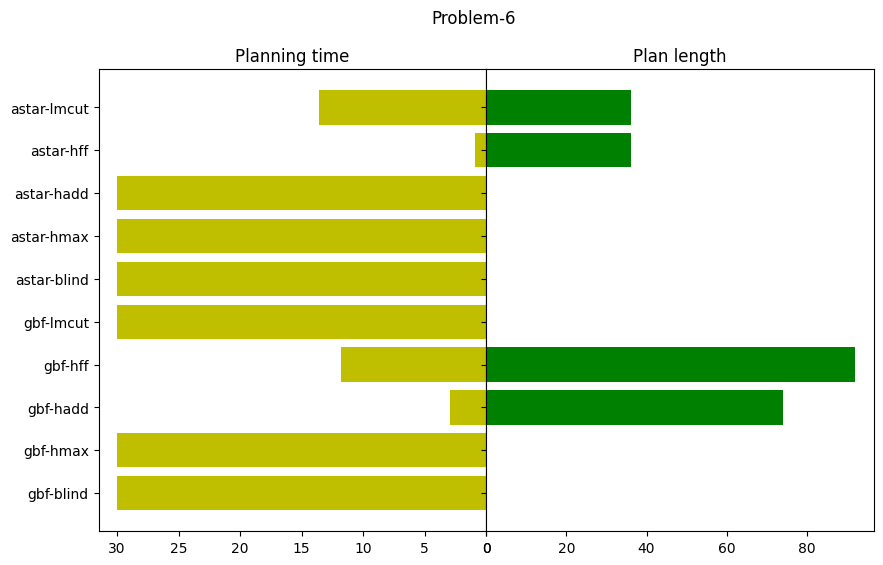

In [24]:
# Uncomment the following line to plot results.
test_all_combinations(timeout=30)

## Construct Reduced Planning Graph (RPG)


### Question
Given a [Pyperplan Task](https://github.com/aibasel/pyperplan/blob/master/pyperplan/task.py) instance and an optional state, return (F_t, A_t), two lists as defined in the RPG pseudo-code from lecture.  Note that _fact names_ in the documentation of `Task` are strings such as '(on a b)' and operator instances are instances of the `Operator` class; the `name` of an operator instance is a string such as '(unstack a c)'.  If state is None, use `task.initial_state`.

For reference, our solution is **15** line(s) of code.

In [25]:
def construct_rpg(task, state=None):
    """Constructs a Relaxed Planning Graph (RPG) for a given Pyperplan Task and
    state.  If state is None, use the initial_state of the task.

    Args:
      task: a Pyperplan Task instance
      state: a set of facts (can be None)

    Returns:
      rpg: A pair (F_sets, A_sets).  Note that F_sets has length one longer than A_sets.  F_sets is a list and the item in the list at F[t] should be a set of fact names.  We expect F_set to be something like "[{'(clear a)', ...}, {'(ontable b)',...}, ...]”.  A_sets is a list and the item in the list at A[t] should be a set of operator instance names.  We expect A_sets to be something like "[{'(unstack a b)', ...}, {'(stack a b)', ... }, ... ]"
    """
    raise NotImplementedError("Implement me!")

### Tests

In [ ]:
def construct_rpg_test1():
    task = get_task_definition_str(BW_BLOCKS_DOMAIN, BW_BLOCKS_PROBLEM_1)
    expected_F_sets = [{'(clear a)', '(on a b)', '(ontable b)', '(handempty)'},
                       {
                           '(ontable b)', '(handempty)', '(clear a)',
                           '(on a b)', '(holding a)', '(clear b)'
                       },
                       {
                           '(handempty)', '(ontable a)', '(holding a)',
                           '(holding b)', '(ontable b)', '(on a a)',
                           '(clear a)', '(on a b)', '(clear b)'
                       }]
    F_sets, A_sets = construct_rpg(task)
    assert len(F_sets) == len(
        expected_F_sets
    ), f"Expected F_sets of length {len(expected_F_sets)}, but got {len(F_sets)}."
    for F_set, expected_F_set in zip(F_sets, expected_F_sets):
        assert F_set == expected_F_set, f"Incorrect F_set: {F_set}"
    expected_A_set_strs = [{'(unstack a b)'},
                           {
                               '(unstack a b)', '(pick-up b)', '(stack a a)',
                               '(stack a b)', '(put-down a)'
                           }]
    assert len(A_sets) == len(
        expected_A_set_strs
    ), f"Expected A_sets of length {len(expected_A_set_strs)}, but got {len(A_sets)}."
    for A_set, expected_A_set_str in zip(A_sets, expected_A_set_strs):
        A_set_str = {a.name for a in A_set}
        assert A_set_str == expected_A_set_str, f"Incorrect A_set: {A_set_str}, expected {expected_A_set_str}"
    return F_sets, [{a.name for a in A_set} for a in A_sets]

construct_rpg_test1()


def construct_rpg_test2():
    task = get_task_definition_str(BW_BLOCKS_DOMAIN, BW_BLOCKS_PROBLEM_2)
    expected_F_sets = [
        {
            '(handempty)', '(clear c)', '(ontable a)', '(on c a)', '(clear b)',
            '(ontable b)'
        },
        {
            '(clear c)', '(holding b)', '(ontable a)', '(holding c)',
            '(clear b)', '(clear a)', '(ontable b)', '(handempty)', '(on c a)'
        },
        {
            '(clear c)', '(holding b)', '(ontable a)', '(holding c)',
            '(on b a)', '(on c c)', '(clear b)', '(holding a)', '(clear a)',
            '(ontable b)', '(handempty)', '(on b b)', '(on b c)', '(on c b)',
            '(on c a)', '(ontable c)'
        },
        {
            '(holding b)', '(ontable a)', '(on c c)', '(clear a)',
            '(ontable b)', '(on b b)', '(on c a)', '(on a b)', '(clear c)',
            '(holding c)', '(on b a)', '(on a a)', '(clear b)', '(holding a)',
            '(on a c)', '(handempty)', '(on b c)', '(on c b)', '(ontable c)'
        },
    ]
    F_sets, A_sets = construct_rpg(task)
    assert len(F_sets) == len(
        expected_F_sets
    ), f"Expected F_sets of length {len(expected_F_sets)}, but got {len(F_sets)}."
    for F_set, expected_F_set in zip(F_sets, expected_F_sets):
        assert F_set == expected_F_set, f"Incorrect F_set: {F_set}"
    expected_A_set_strs = [
        {'(unstack c a)', '(pick-up b)'},
        {
            '(unstack c a)', '(pick-up b)', '(stack b a)', '(stack b c)',
            '(put-down c)', '(stack c a)', '(stack c c)', '(put-down b)',
            '(stack c b)', '(pick-up a)', '(stack b b)'
        },
        {
            '(stack b a)', '(stack b c)', '(unstack b b)', '(stack c c)',
            '(stack c b)', '(unstack c b)', '(unstack b c)', '(stack a b)',
            '(put-down a)', '(stack a c)', '(pick-up a)', '(stack a a)',
            '(unstack c a)', '(pick-up b)', '(put-down c)', '(stack c a)',
            '(put-down b)', '(unstack b a)', '(stack b b)', '(pick-up c)',
            '(unstack c c)'
        },
    ]
    assert len(A_sets) == len(
        expected_A_set_strs
    ), f"Expected A_sets of length {len(expected_A_set_strs)}, but got {len(A_sets)}."
    for A_set, expected_A_set_str in zip(A_sets, expected_A_set_strs):
        assert {a.name for a in A_set
               } == expected_A_set_str, f"Incorrect A_set: {A_set}"
    return F_sets, [{a.name for a in A_set} for a in A_sets]

construct_rpg_test2()

print('Tests passed.')

## Implement h_add


### Question
Given a [Pyperplan Task](https://github.com/aibasel/pyperplan/blob/master/pyperplan/task.py) instance and
    a state (set of facts or None), return h_add(state).

For reference, our solution is **7** line(s) of code.

In addition to all the utilities defined at the top of the Colab notebook, the following functions are available in this question environment: `construct_rpg`. You may not need to use all of them.

In [ ]:
def h_add(task, state=None):
    """Computes h_add for a given Pyperplan Task and state.  If state is None,
    use the initial_state of the task.

    Args:
      task: a pyperplan Task instance
      state: a set of facts (can be None)

    Returns:
      h: an integer
    """
    raise NotImplementedError("Implement me!")

### Tests

In [ ]:
def h_add_test1():
    return h_add_test(BW_BLOCKS_PROBLEM_1, 3)

h_add_test1()


def h_add_test2():
    return h_add_test(BW_BLOCKS_PROBLEM_2, 5)

h_add_test2()


def h_add_test3():
    return h_add_test(BW_BLOCKS_PROBLEM_3, 21)

h_add_test3()


def h_add_test4():
    return h_add_test(BW_BLOCKS_PROBLEM_4, 30)

h_add_test4()

print('Tests passed.')

## Implement h_ff (OPTIONAL)


### Question
Given a [Pyperplan Task](https://github.com/aibasel/pyperplan/blob/master/pyperplan/task.py) and a state (set of facts or None), return h_ff(state).

For reference, our solution is **26** line(s) of code.

In addition to all the utilities defined at the top of the Colab notebook, the following functions are available in this question environment: `construct_rpg`. You may not need to use all of them.

In [ ]:
def h_ff(task, state=None):
    """Computes h_ff for a given task and state.  If state is None, use the
    initial_state of the task.

    Args:
      task: a Pyperplan Task instance
      state: a set of facts (can be None)

    Returns:
      h: an integer
    """
    raise NotImplementedError("Implement me!")

### Tests

In [ ]:
def h_ff_test1():
    return h_ff_test(BW_BLOCKS_PROBLEM_1, 2)

h_ff_test1()


def h_ff_test2():
    return h_ff_test(BW_BLOCKS_PROBLEM_2, 5)

h_ff_test2()


def h_ff_test3():
    return h_ff_test(BW_BLOCKS_PROBLEM_3, 12)

h_ff_test3()


def h_ff_test4():
    return h_ff_test(BW_BLOCKS_PROBLEM_4, 16)

h_ff_test4()

print('Tests passed.')